In [17]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import datetime
import logging
import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import sys

In [24]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('stock_trader.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

# Default configuration
DEFAULT_CONFIG = {
    "model": {
        "input_size": 5,
        "hidden_size": 128,
        "num_layers": 3,
        "dropout": 0.3
    },
    "training": {
        "lookback": 360,
        "test_size": 60,
        "batch_size": 32,
        "epochs": 12,
        "learning_rate": 0.001
    },
    "trading": {
        "initial_budget": 1000,
        "buy_threshold": 0.1,
        "sell_threshold": -0.1,
        "stop_loss": 0.995
    }
}

In [25]:
class ConfigManager:
    @staticmethod
    def load_config(config_path: Optional[str] = None) -> Dict:
        """Load configuration from file or return default config."""
        if config_path and Path(config_path).exists():
            try:
                with open(config_path, 'r') as f:
                    config = json.load(f)
                logger.info(f"Loaded configuration from {config_path}")
                return config
            except Exception as e:
                logger.error(f"Error loading config: {e}")
                logger.info("Using default configuration")
                return DEFAULT_CONFIG
        return DEFAULT_CONFIG

In [26]:
class StockDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]

In [27]:
class LSTMPredictor(nn.Module):
    def __init__(self, config: Dict):
        super(LSTMPredictor, self).__init__()
        self.hidden_size = config['model']['hidden_size']
        self.num_layers = config['model']['num_layers']

        self.lstm = nn.LSTM(
            input_size=config['model']['input_size'],
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            dropout=config['model']['dropout'],
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(self.hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        lstm_out, _ = self.lstm(x, (h0, c0))
        last_time_step = lstm_out[:, -1, :]

        return self.fc(last_time_step)


In [30]:
class StockTrader:
    def __init__(self, config_path: Optional[str] = None):
        """Initialize StockTrader with configuration."""
        self.config = ConfigManager.load_config(config_path)
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = None
        self.scaler = MinMaxScaler()
        self.initial_budget = self.config['trading']['initial_budget']
        self.budget = self.initial_budget
        self.position = 0
        self.trades = []
        self.best_state = None

        logger.info(f"Initialized StockTrader with device: {self.device}")

    def prepare_data(self, data: pd.DataFrame, lookback: int = None) -> Tuple[np.ndarray, np.ndarray]:
        """Prepare data for training."""
        if lookback is None:
            lookback = self.config['training']['lookback']

        try:
            features = ['Open', 'High', 'Low', 'Close', 'Volume']
            scaled_data = self.scaler.fit_transform(data[features])

            X, y = [], []
            for i in range(lookback, len(scaled_data)):
                X.append(scaled_data[i-lookback:i])
                y.append(scaled_data[i, features.index('Close')])

            return np.array(X), np.array(y)
        except Exception as e:
            logger.error(f"Error preparing data: {e}")
            raise

    def download_data(self, symbol: str, days: int = 7) -> Optional[pd.DataFrame]:
        """Download stock data with error handling."""
        try:
            end_date = datetime.datetime.now()
            start_date = end_date - datetime.timedelta(days=days)
            data = yf.download(symbol, start=start_date, end=end_date, interval='1m')

            if data.empty:
                logger.error(f"No data received for symbol {symbol}")
                return None

            logger.info(f"Successfully downloaded data for {symbol}")
            return data
        except Exception as e:
            logger.error(f"Error downloading data for {symbol}: {e}")
            return None

    def train_model(self, train_loader: DataLoader, test_loader: DataLoader) -> None:
        """Train the model with error handling and logging."""
        try:
            self.model = LSTMPredictor(self.config).to(self.device)
            criterion = nn.MSELoss()
            optimizer = torch.optim.Adam(
                self.model.parameters(),
                lr=self.config['training']['learning_rate']
            )

            best_loss = float('inf')
            epochs = self.config['training']['epochs']

            for epoch in range(epochs):
                self.model.train()
                total_loss = 0
                pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

                for batch_X, batch_y in pbar:
                    batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

                    optimizer.zero_grad()
                    outputs = self.model(batch_X)
                    loss = criterion(outputs.squeeze(), batch_y)

                    loss.backward()
                    optimizer.step()

                    total_loss += loss.item()
                    pbar.set_postfix({'loss': total_loss/len(train_loader)})

                # Validation
                val_loss = self.validate_model(test_loader, criterion)
                logger.info(f'Epoch {epoch+1}/{epochs} - Validation Loss: {val_loss:.6f}')

                if val_loss < best_loss:
                    best_loss = val_loss
                    self.best_state = self.model.state_dict().copy()
                    logger.info(f'New best model saved with validation loss: {val_loss:.6f}')

        except Exception as e:
            logger.error(f"Error during training: {e}")
            raise

    def validate_model(self, test_loader: DataLoader, criterion: nn.Module) -> float:
        """Validate the model."""
        self.model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                outputs = self.model(batch_X)
                val_loss += criterion(outputs.squeeze(), batch_y).item()
        return val_loss / len(test_loader)

    def simulate_trading(self, data: pd.DataFrame, predictions: np.ndarray) -> None:
        self.budget = self.initial_budget
        self.position = 0
        self.trades = []
        predictions = predictions.reshape(-1, 1)

        dummy_data = np.zeros((predictions.shape[0], self.scaler.n_features_in_))
        dummy_data[:, 3] = predictions[:, 0]
        predicted_prices = self.scaler.inverse_transform(dummy_data)[:, 3]

        for i in range(1, len(predictions)):
            current_price = data['Close'].iloc[i].item()
            pred_change_pct = (predicted_prices[i] - current_price) / current_price * 100

            # Более агрессивная торговля
            if pred_change_pct > -0.2 and self.position == 0:  # Покупаем почти всегда
                shares = self.budget / current_price
                self.position = shares
                self.budget = 0
                self.trades.append(('buy', i, current_price))
                print(f"Buy at {current_price:.2f} (predicted change: {pred_change_pct:.2f}%)")

            elif pred_change_pct < 0.2 and self.position > 0:  # Продаем почти всегда
                self.budget = self.position * current_price
                self.position = 0
                self.trades.append(('sell', i, current_price))
                print(f"Sell at {current_price:.2f} (predicted change: {pred_change_pct:.2f}%)")

    def train(self, symbol: str) -> Optional[Tuple[np.ndarray, np.ndarray]]:
        """Main training function with error handling."""
        try:
            data = self.download_data(symbol)
            if data is None:
                return None

            lookback = self.config['training']['lookback']
            test_size = self.config['training']['test_size']
            batch_size = self.config['training']['batch_size']

            if len(data) < (lookback + test_size):
                logger.warning(f"Not enough data for {symbol}")
                return None

            X, y = self.prepare_data(data, lookback)

            train_size = len(X) - test_size
            X_train, X_test = X[:train_size], X[train_size:]
            y_train, y_test = y[:train_size], y[train_size:]

            train_dataset = StockDataset(X_train, y_train)
            test_dataset = StockDataset(X_test, y_test)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            test_loader = DataLoader(test_dataset, batch_size=batch_size)

            logger.info(f"Starting training for {symbol}")
            self.train_model(train_loader, test_loader)

            if self.best_state is not None:
                self.model.load_state_dict(self.best_state)
            else:
                logger.warning("No best model state found. Using the current model state.")

            test_pred = self.predict(X_test)
            self.simulate_trading(data.iloc[lookback:].reset_index(), test_pred)
            self.plot_results(data.iloc[lookback:].reset_index(), test_pred, symbol)

            return test_pred, y_test

        except Exception as e:
            logger.error(f"Error during training process for {symbol}: {e}")
            return None

    def save_model(self, path: str) -> None:
        """Save the trained model."""
        try:
            if self.best_state is not None:
                torch.save({
                    'model_state_dict': self.best_state,
                    'scaler': self.scaler,
                    'config': self.config
                }, path)
                logger.info(f"Model saved to {path}")
            else:
                logger.warning("No model state to save")
        except Exception as e:
            logger.error(f"Error saving model: {e}")

    def load_model(self, path: str) -> bool:
        """Load a trained model."""
        try:
            if not Path(path).exists():
                logger.error(f"Model file not found: {path}")
                return False

            checkpoint = torch.load(path)
            self.config = checkpoint['config']
            self.model = LSTMPredictor(self.config).to(self.device)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.scaler = checkpoint['scaler']
            self.best_state = checkpoint['model_state_dict']
            logger.info(f"Model loaded from {path}")
            return True
        except Exception as e:
            logger.error(f"Error loading model: {e}")
            return False

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Make predictions with error handling."""
        try:
            self.model.eval()
            with torch.no_grad():
                X = torch.FloatTensor(X).to(self.device)
                return self.model(X).cpu().numpy()
        except Exception as e:
            logger.error(f"Error during prediction: {e}")
            raise

    def plot_results(self, data: pd.DataFrame, predictions: np.ndarray, symbol: str) -> None:
        try:
            plt.figure(figsize=(15, 7))

            # Убедимся что мы работаем с правильными размерностями
            predictions = predictions.reshape(-1)
            data = data.iloc[-len(predictions):].reset_index()  # Берём только нужное количество точек
            times = data['Datetime']
            times = [t.strftime('%H:%M') for t in times]

            # Строим график реальных цен
            plt.plot(times, data['Close'], label='Actual Price', alpha=0.7)

            # Преобразуем предсказания обратно в цены
            dummy_data = np.zeros((len(predictions), self.scaler.n_features_in_))
            dummy_data[:, 3] = predictions
            predicted_prices = self.scaler.inverse_transform(dummy_data)[:, 3]
            plt.plot(times, predicted_prices, label='Predicted Price', alpha=0.7, linestyle='--')

            # Отмечаем точки покупки/продажи
            buy_indices = [trade[1] for trade in self.trades if trade[0] == 'buy']
            sell_indices = [trade[1] for trade in self.trades if trade[0] == 'sell']

            if buy_indices:
                buy_prices = [data['Close'].iloc[i] for i in buy_indices if i < len(data)]
                buy_times = [times[i] for i in buy_indices if i < len(data)]
                plt.scatter(buy_times, buy_prices, color='green', marker='^', s=100, label='Buy')

            if sell_indices:
                sell_prices = [data['Close'].iloc[i] for i in sell_indices if i < len(data)]
                sell_times = [times[i] for i in sell_indices if i < len(data)]
                plt.scatter(sell_times, sell_prices, color='red', marker='v', s=100, label='Sell')

            # Вычисляем финальную стоимость и прибыль/убыток
            final_value = self.budget if self.budget > 0 else self.position * data['Close'].iloc[-1]
            profit_loss = ((final_value - self.initial_budget) / self.initial_budget) * 100

            plt.title(f'Trading Results for {symbol}\nFinal Value: ${final_value:.2f} ({"+" if profit_loss >= 0 else ""}{profit_loss:.2f}%)')
            plt.xlabel('Time')
            plt.ylabel('Price')
            plt.xticks(rotation=45)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.error(f"Error plotting results: {e}")
            plt.close()

[*********************100%***********************]  1 of 1 completed
Epoch 1/12:  95%|█████████▌| 41/43 [00:00<00:00, 60.11it/s, loss=0.0389]/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 12/12: 100%|██████████| 43/43 [00:00<00:00, 61.72it/s, loss=0.00329]


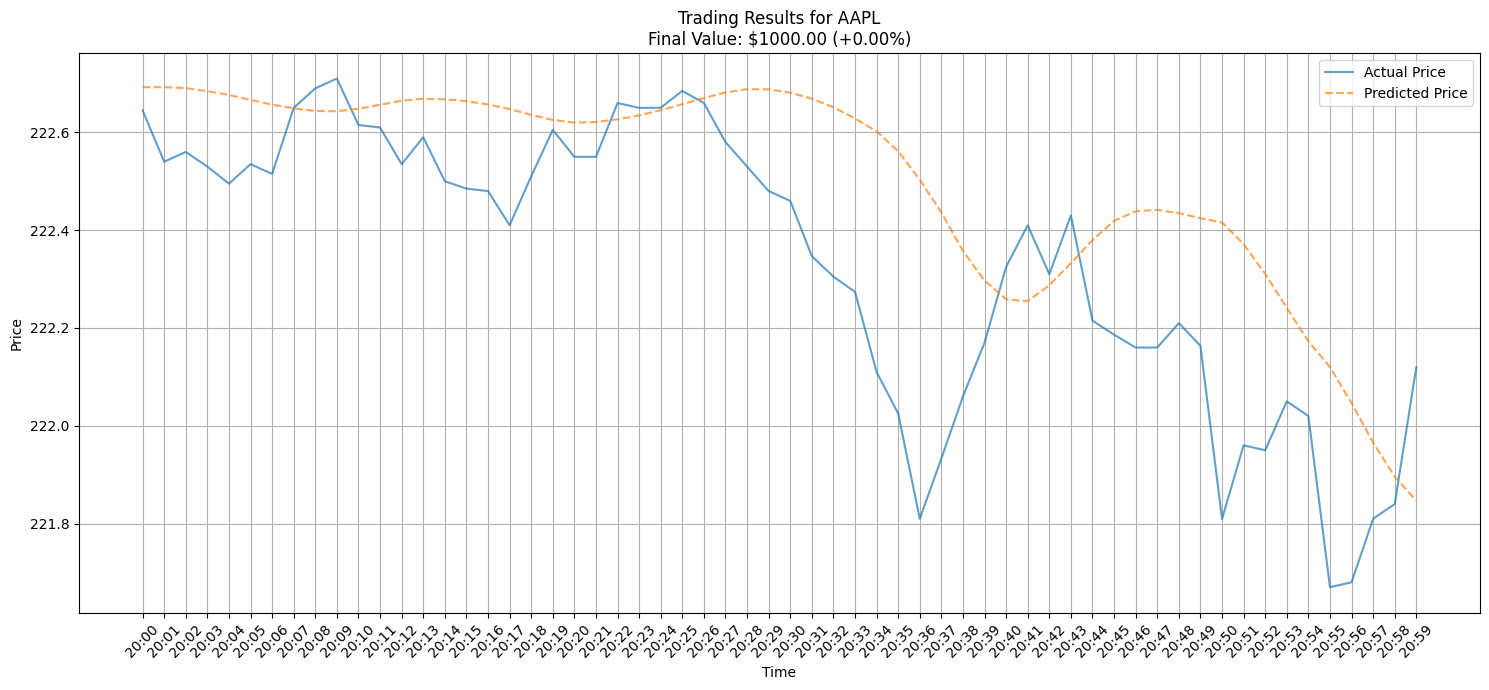

[*********************100%***********************]  1 of 1 completed
Epoch 1/12:  98%|█████████▊| 42/43 [00:00<00:00, 63.23it/s, loss=0.0593]/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 12/12: 100%|██████████| 43/43 [00:00<00:00, 61.35it/s, loss=0.00589]


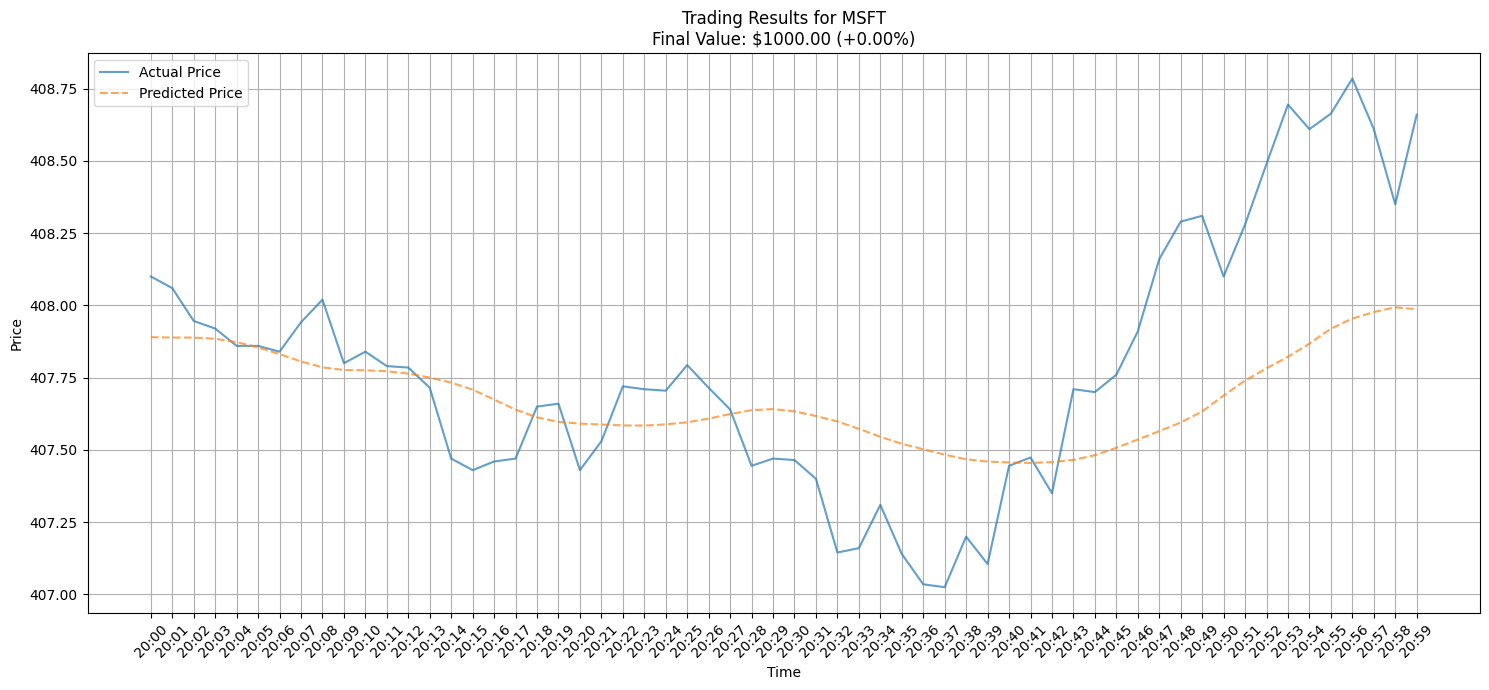

[*********************100%***********************]  1 of 1 completed
Epoch 1/12:  98%|█████████▊| 42/43 [00:00<00:00, 60.26it/s, loss=0.115]/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 12/12: 100%|██████████| 43/43 [00:00<00:00, 63.10it/s, loss=0.00977]


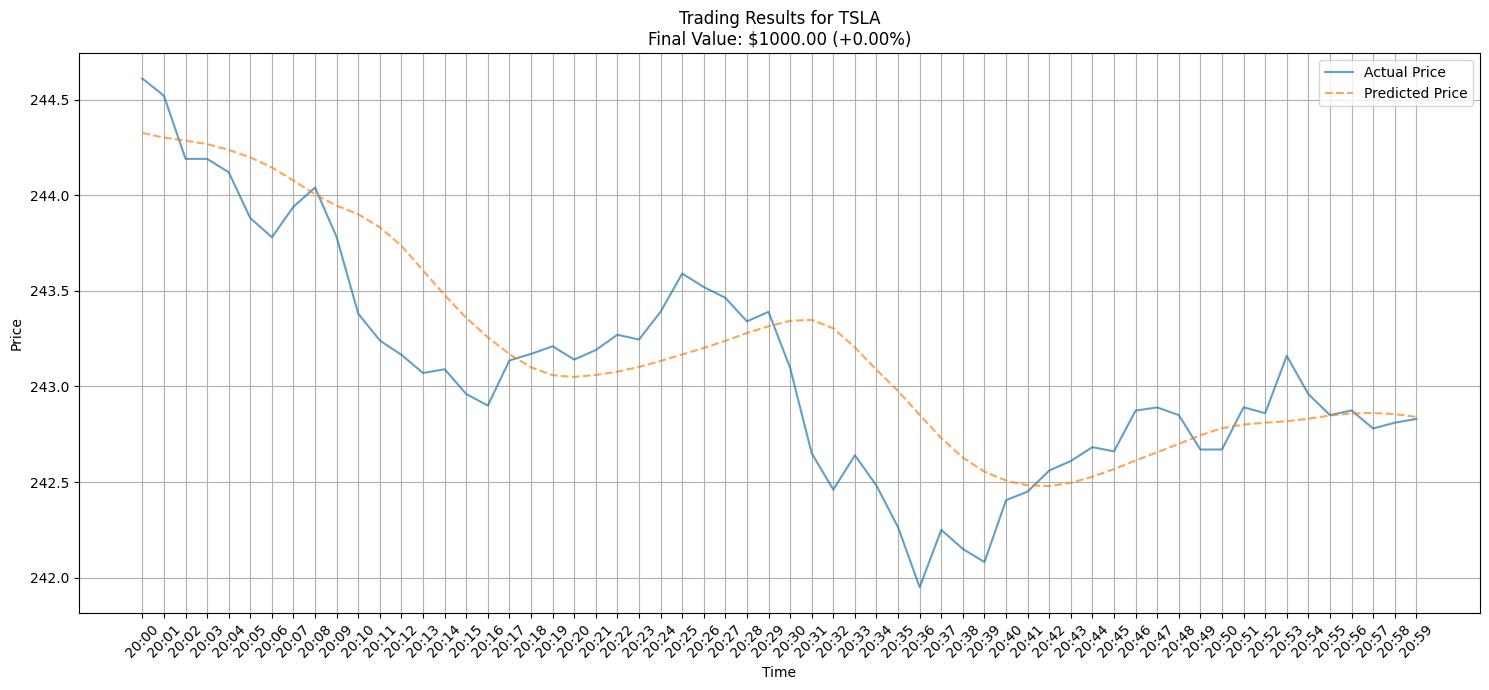

[*********************100%***********************]  1 of 1 completed
Epoch 12/12: 100%|██████████| 42/42 [00:00<00:00, 62.42it/s, loss=0.00335]


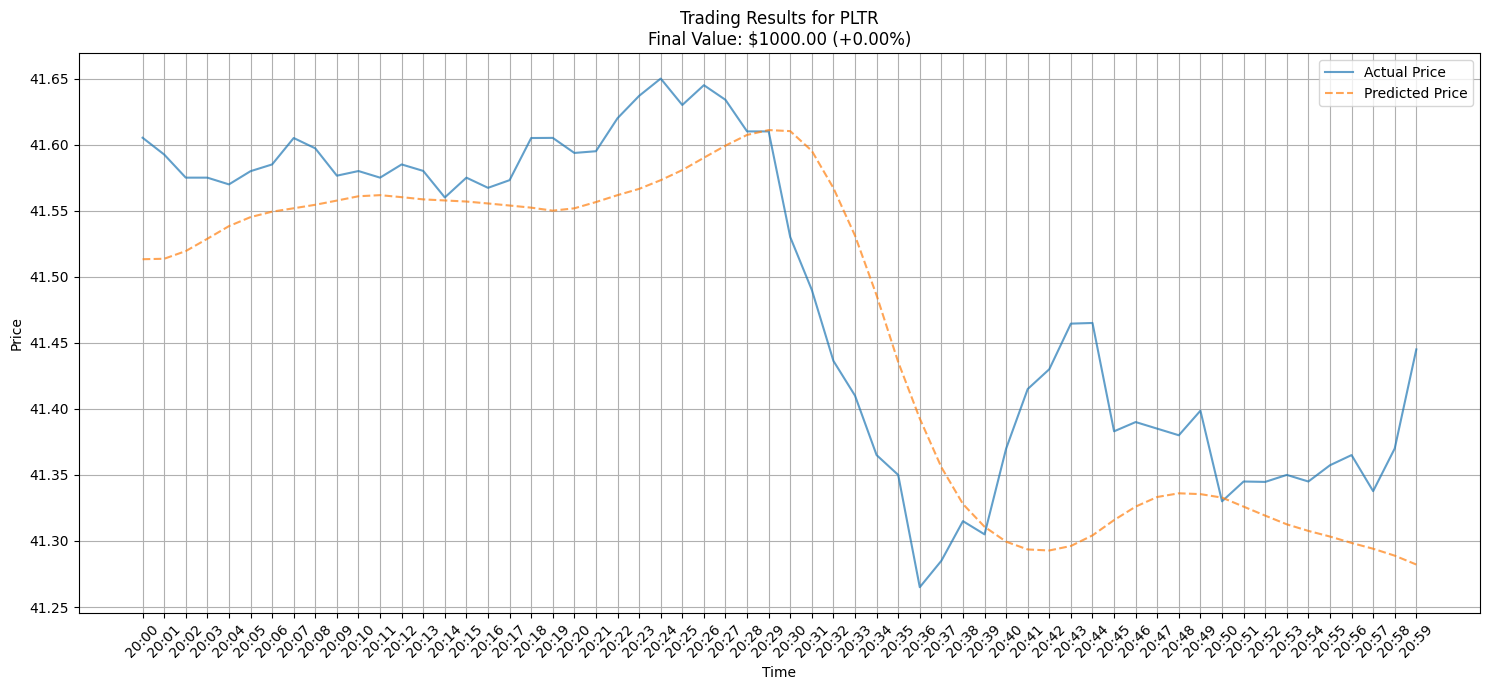

In [32]:
symbols = ['AAPL', 'MSFT', 'TSLA', 'PLTR']
trader = StockTrader()

for symbol in symbols:
    trader.train(symbol)